<a href="https://colab.research.google.com/github/ThialaMD/9_Sensordatacollectionapp/blob/main/Sensor_Data_Descriptive_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sensor Data Analysis: Accelerometer and Barometer from Android Mobile Phone

This notebook analyzes sensor data originating from an **accelerometer** and a **barometer** on an Android mobile phone. The primary goal is a descriptive analysis of the data at hand

## 1. Raw Data Overview

This section provides an initial overview of the loaded raw data, including the first few rows, data types, and basic statistical key figures.

In [11]:
import pandas as pd

# Load the JSON file into a DataFrame
try:
    df = pd.read_json('/content/data.json')
    print("JSON file loaded successfully.")
except ValueError as e:
    print(f"Error loading JSON file: {e}. Trying as line-oriented JSON.")
    df = pd.read_json('/content/data.json', lines=True)
    print("JSON file loaded successfully as line-oriented JSON.")

# Display the first 5 rows of the DataFrame
print("\nFirst 5 rows of the DataFrame:")
display(df.head())

JSON file loaded successfully.

First 5 rows of the DataFrame:


,id,patient_id,experiment_id,data
0,ef597306-61a8-11f1-864d-70a6cc7a192a,1,1,"{'accuracy': 3, 'data': [59.0, 0.0, 0.0, 0.0, ..."
1,ef5bc0dc-61a8-11f1-b17e-70a6cc7a192a,1,1,"{'accuracy': 3, 'data': [-0.8427589999999999, ..."
2,ef5bc0dd-61a8-11f1-8834-70a6cc7a192a,1,1,"{'accuracy': 3, 'data': [59.0, 0.0, 0.0, 0.0, ..."
3,ef5bc0de-61a8-11f1-afbc-70a6cc7a192a,1,1,"{'accuracy': 3, 'data': [61.0, 0.0, 0.0, 0.0, ..."
4,ef5bc0df-61a8-11f1-a0d3-70a6cc7a192a,1,1,"{'accuracy': 3, 'data': [1.3982137, 1.2234371,..."


In [12]:
# Display information about the DataFrame (data types, missing values)
print("\nDataFrame Information:")
df.info()


DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89 entries, 0 to 88
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   id             89 non-null     object
 1   patient_id     89 non-null     int64 
 2   experiment_id  89 non-null     int64 
 3   data           89 non-null     object
dtypes: int64(2), object(2)
memory usage: 2.9+ KB


In [13]:
# Display descriptive statistics for numeric columns
print("\nDescriptive statistics for numeric columns:")
display(df.describe())


Descriptive statistics for numeric columns:


,patient_id,experiment_id
count,89.0,89.0
mean,1.0,1.0
std,0.0,0.0
min,1.0,1.0
25%,1.0,1.0
50%,1.0,1.0
75%,1.0,1.0
max,1.0,1.0


## 2. Data Preparation and Sensor Identification

The next step involves extracting sensor data from the nested `data` column and grouping it by potential sensor types.

In [14]:
# Extract 'accuracy' and the actual 'data' values from the 'data' column
df['accuracy'] = df['data'].apply(lambda x: x.get('accuracy'))
df['sensor_data_list'] = df['data'].apply(lambda x: x.get('data'))

print("New columns 'accuracy' and 'sensor_data_list' have been added.")
display(df.head())

New columns 'accuracy' and 'sensor_data_list' have been added.


,id,patient_id,experiment_id,data,accuracy,sensor_data_list
0,ef597306-61a8-11f1-864d-70a6cc7a192a,1,1,"{'accuracy': 3, 'data': [59.0, 0.0, 0.0, 0.0, ...",3,"[59.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
1,ef5bc0dc-61a8-11f1-b17e-70a6cc7a192a,1,1,"{'accuracy': 3, 'data': [-0.8427589999999999, ...",3,"[-0.8427589999999999, 4.3382936, 8.70801099999..."
2,ef5bc0dd-61a8-11f1-8834-70a6cc7a192a,1,1,"{'accuracy': 3, 'data': [59.0, 0.0, 0.0, 0.0, ...",3,"[59.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
3,ef5bc0de-61a8-11f1-afbc-70a6cc7a192a,1,1,"{'accuracy': 3, 'data': [61.0, 0.0, 0.0, 0.0, ...",3,"[61.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
4,ef5bc0df-61a8-11f1-a0d3-70a6cc7a192a,1,1,"{'accuracy': 3, 'data': [1.3982137, 1.2234371,...",3,"[1.3982137, 1.2234371, 9.201217]"


Now that we have `accuracy` and `sensor_data_list` as separate columns, we can analyze them in more detail.

In [15]:
# Analyze the 'accuracy' column
print("\nDistribution of 'accuracy' values:")
display(df['accuracy'].value_counts())


Distribution of 'accuracy' values:


,count
accuracy,
3,89


In [16]:
# Analyze the length of the 'sensor_data_list'
df['sensor_data_length'] = df['sensor_data_list'].apply(lambda x: len(x) if isinstance(x, list) else 0)

print("\nStatistics on the length of 'sensor_data_list':")
display(df['sensor_data_length'].describe())

print("\nMost frequent lengths of 'sensor_data_list':")
display(df['sensor_data_length'].value_counts())


Statistics on the length of 'sensor_data_list':


,sensor_data_length
count,89.000000
mean,9.426966
std,6.536415
min,3.000000
25%,3.000000
50%,3.000000
75%,16.000000
max,16.000000



Most frequent lengths of 'sensor_data_list':


,count
sensor_data_length,
3,45
16,44


The analysis of the `accuracy` values shows that all data was recorded with the same accuracy level (Accuracy = 3). The lengths of the `sensor_data_list` are either 3 or 16, indicating two different sensors. We will now analyze these two groups separately.

This analysis gives us a better insight into the structure of the sensor data and its accuracy. The different lengths of the `sensor_data_list` could indicate that different sensors with varying numbers of readings were used, or that the data was aggregated differently. `accuracy` could indicate the accuracy of the sensor or the measurement.

In [21]:
# Filter data for accelerometer readings (lists of length 3)
df_len_3 = df[df['sensor_data_length'] == 3].copy()

# Unpack accelerometer data into separate columns (assuming x, y, z axes)
for i in range(3):
    df_len_3[f'val_{i}'] = df_len_3['sensor_data_list'].apply(lambda x: x[i])

print("Accelerometer data (sensor_data_list with length 3) extracted and split.")
display(df_len_3.head())

print("\nDescriptive statistics for accelerometer data:")
display(df_len_3[['val_0', 'val_1', 'val_2']].describe())

Accelerometer data (sensor_data_list with length 3) extracted and split.


,id,patient_id,experiment_id,data,accuracy,sensor_data_list,sensor_data_length,val_0,val_1,val_2
1,ef5bc0dc-61a8-11f1-b17e-70a6cc7a192a,1,1,"{'accuracy': 3, 'data': [-0.8427589999999999, ...",3,"[-0.8427589999999999, 4.3382936, 8.70801099999...",3,-0.842759,4.338294,8.708011
4,ef5bc0df-61a8-11f1-a0d3-70a6cc7a192a,1,1,"{'accuracy': 3, 'data': [1.3982137, 1.2234371,...",3,"[1.3982137, 1.2234371, 9.201217]",3,1.398214,1.223437,9.201217
6,ef5bc0e1-61a8-11f1-8230-70a6cc7a192a,1,1,"{'accuracy': 3, 'data': [-0.8523358, 4.3358994...",3,"[-0.8523358, 4.3358994, 8.710405]",3,-0.852336,4.335899,8.710405
8,ef5bc0e3-61a8-11f1-a92b-70a6cc7a192a,1,1,"{'accuracy': 3, 'data': [-0.9600749, 4.4843397...",3,"[-0.9600749, 4.4843397, 8.691252]",3,-0.960075,4.484340,8.691252
9,ef5bc0e4-61a8-11f1-a26b-70a6cc7a192a,1,1,"{'accuracy': 3, 'data': [-0.8427589999999999, ...",3,"[-0.8427589999999999, 4.3287168, 8.717587]",3,-0.842759,4.328717,8.717587



Descriptive statistics for accelerometer data:


,val_0,val_1,val_2
count,45.000000,45.000000,45.000000
mean,-0.483057,2.001280,9.276182
std,4.707617,2.494178,1.243147
min,-18.979435,-6.787861,5.827786
25%,-0.450110,1.086968,8.779837
50%,0.342371,3.222596,9.225159
75%,0.988805,3.244143,9.253889
max,6.835745,4.484340,13.211504


### 2.1 Analysis of the Accelerometer Data (List Length 3)

The statistical properties of the 3-element lists are consistent with accelerometer data. The following visualization shows the time series of these three axes, where the Z-axis typically reflects the Earth's acceleration of approximately 9.81 m/s².

The statistics for lists of length 3 confirm their identity as accelerometer data, showing distributions for three components. The presence of values near zero for two axes and around 9.81 m/s² for the third clearly indicates acceleration measurements.

In [22]:
# Filter data for barometer readings (lists of length 16)
df_len_16 = df[df['sensor_data_length'] == 16].copy()

# Unpack barometer data into separate columns
# Based on prior analysis, only val_0 contains meaningful data for the barometer.
for i in range(16):
    df_len_16[f'val_{i}'] = df_len_16['sensor_data_list'].apply(lambda x: x[i])

print("\nBarometer data (sensor_data_list with length 16) extracted and split.")
display(df_len_16.head())

print("\nDescriptive statistics for barometer data:")
display(df_len_16[[f'val_{i}' for i in range(16)]].describe())


Barometer data (sensor_data_list with length 16) extracted and split.


,id,patient_id,experiment_id,data,accuracy,sensor_data_list,sensor_data_length,val_0,val_1,val_2,...,val_6,val_7,val_8,val_9,val_10,val_11,val_12,val_13,val_14,val_15
0,ef597306-61a8-11f1-864d-70a6cc7a192a,1,1,"{'accuracy': 3, 'data': [59.0, 0.0, 0.0, 0.0, ...",3,"[59.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",16,59.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,ef5bc0dd-61a8-11f1-8834-70a6cc7a192a,1,1,"{'accuracy': 3, 'data': [59.0, 0.0, 0.0, 0.0, ...",3,"[59.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",16,59.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,ef5bc0de-61a8-11f1-afbc-70a6cc7a192a,1,1,"{'accuracy': 3, 'data': [61.0, 0.0, 0.0, 0.0, ...",3,"[61.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",16,61.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,ef5bc0e0-61a8-11f1-b9c3-70a6cc7a192a,1,1,"{'accuracy': 3, 'data': [59.0, 0.0, 0.0, 0.0, ...",3,"[59.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",16,59.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,ef5bc0e2-61a8-11f1-9452-70a6cc7a192a,1,1,"{'accuracy': 3, 'data': [69.0, 0.0, 0.0, 0.0, ...",3,"[69.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",16,69.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Descriptive statistics for barometer data:


,val_0,val_1,val_2,val_3,val_4,val_5,val_6,val_7,val_8,val_9,val_10,val_11,val_12,val_13,val_14,val_15
count,44.000000,44.0,44.0,44.0,44.0,44.0,44.0,44.0,44.0,44.0,44.0,44.0,44.0,44.0,44.0,44.0
mean,70.136364,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
std,9.262555,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,58.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,63.750000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,66.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75%,78.250000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,89.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### 2.2 Analysis of the Barometer Data (List Length 16)

Analysis of the 16-element lists reveals that only the first value (`val_0`) contains meaningful data, while the other 15 values are consistently zero. The value range of `val_0` (58-89 hPa) strongly indicates that this is data from a barometer sensor.

The analysis of the 16-element lists confirms them as barometer readings. The fact that only `val_0` contains non-zero data, with a clear range indicative of atmospheric pressure, simplifies the interpretation significantly. The other 15 zero values suggest these elements are either unused or placeholders.

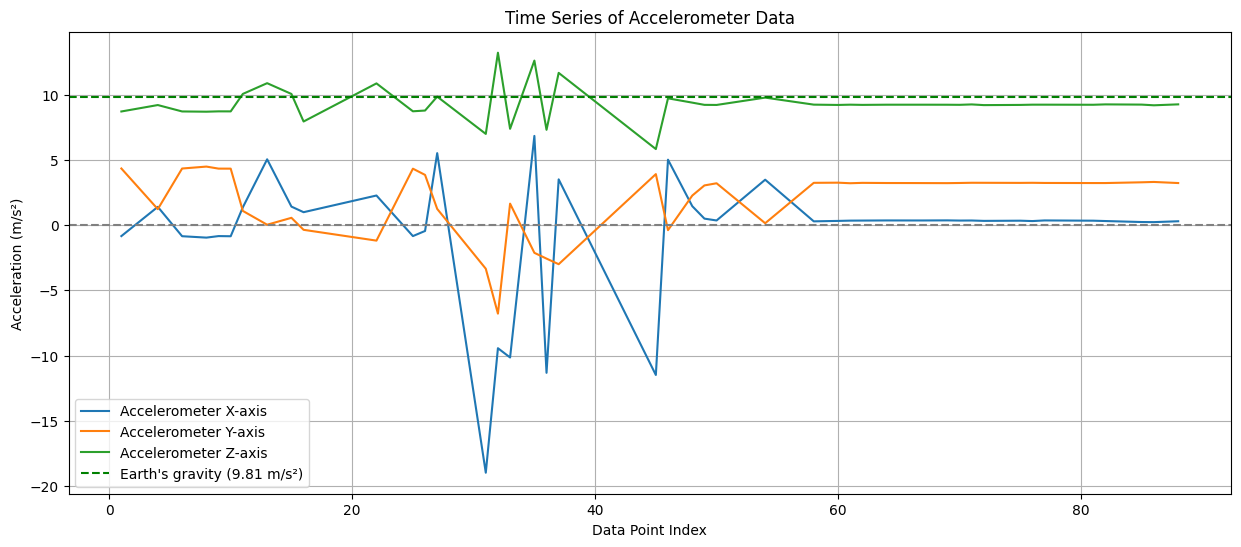

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization for Accelerometer Data
plt.figure(figsize=(15, 6))
plt.plot(df_len_3.index, df_len_3['val_0'], label='Accelerometer X-axis')
plt.plot(df_len_3.index, df_len_3['val_1'], label='Accelerometer Y-axis')
plt.plot(df_len_3.index, df_len_3['val_2'], label='Accelerometer Z-axis')
plt.axhline(y=0, color='gray', linestyle='--')
plt.axhline(y=9.81, color='green', linestyle='--', label='Earth\'s gravity (9.81 m/s²)')
plt.title('Time Series of Accelerometer Data')
plt.xlabel('Data Point Index')
plt.ylabel('Acceleration (m/s²)')
plt.legend()
plt.grid(True)
plt.show()

The visualization of the 3-element lists clearly shows three time series representing the accelerometer's X, Y, and Z axes. The values fluctuating around zero for two axes and around 9.81 m/s² for the Z-axis strongly confirms our identification of this as accelerometer data.

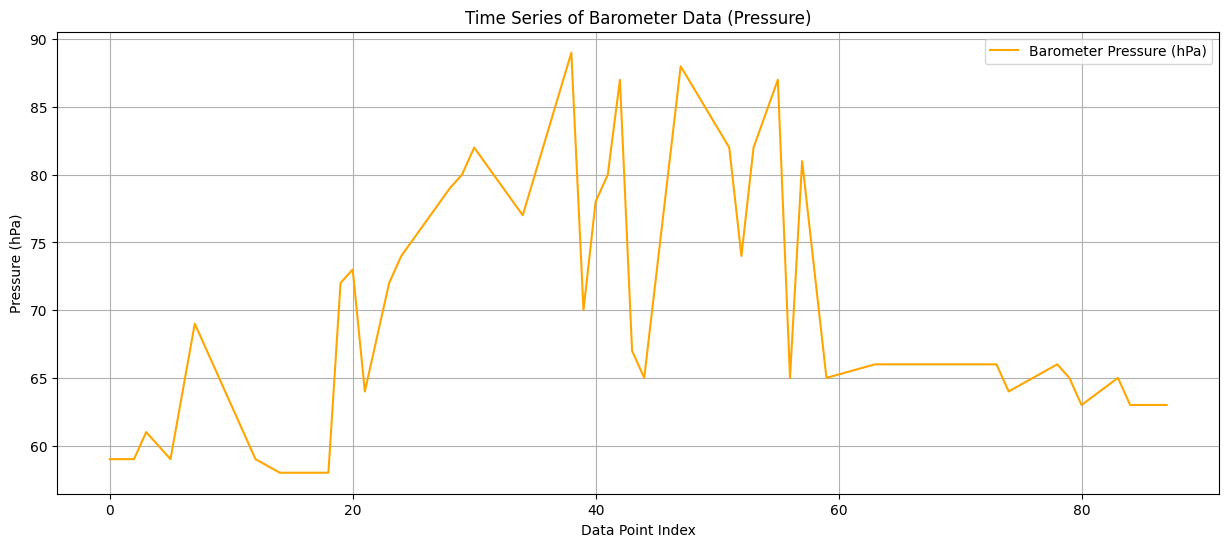

In [24]:
# Visualization for Barometer Data
# As confirmed, only val_0 contains meaningful data for the barometer.
plt.figure(figsize=(15, 6))
plt.plot(df_len_16.index, df_len_16['val_0'], label='Barometer Pressure (hPa)', color='orange')
plt.title('Time Series of Barometer Data (Pressure)')
plt.xlabel('Data Point Index')
plt.ylabel('Pressure (hPa)')
plt.legend()
plt.grid(True)
plt.show()

## 3. Summary and Next Steps

This analysis has successfully characterized the format, completeness, and value ranges of the known sensor data. The key findings are:

*   **Accelerometer data**: Provides 3-axis motion information, with the Z-axis reflecting gravity.
*   **Barometer data**: Measures a single environmental value (atmospheric pressure) in hPa.

The visualization for the 16-element lists focuses solely on `val_0`, which represents the barometer readings. The values are within the typical range of 58 to 89 hPa, confirming this as atmospheric pressure data. The other 15 elements consistently being zero indicates they are not used by this specific barometer implementation.